# Detection of an unknown pulsar and measurement of its period
## Crab Pulsar Experiement Part 3.1

Use this notebook as a template to complate Part 3.1 of the lab script. Use the notebook to annotate your code and document the program. You can print this later and include as part of your lab book.

To begin, start by executing each of the cells in turn to see how the demo program works.

In [1]:
# To begin, we import some libraries that we will need later.

# Some handy standard python libraries
import os

# The numpy library will allow us to do FFTs
import numpy as np

# The pyplot module from matplotlib will allow us to plot things.
from  matplotlib import pyplot as plt

# pi is a useful value!
from math import pi


## Reference manuals

There are many useful python libraries. You may find the following links helpful in programming your code

 * [Numpy FFT module](https://docs.scipy.org/doc/numpy-1.13.0/reference/routines.fft.html)

 * [Matplotlib manual](https://matplotlib.org/api/pyplot_api.html)

## Getting at the data

There are 5 data files avaliable, each with a different pulsar signal. The sample code below will print the names of the data files to the screen. Each data file has an associated header file which contains useful information about the data. Change the variables "myfile" and "hdrfile" to select which file you want to work on. Remeber that you have to re-run all the following code if you have changed the file. A useful command could be to select "Cell" -> "Run All Below", from the menu.

In [2]:
# Connect (mount) your google drive as a virtual directory accessible by this python code.
from google.colab import drive         # Import the python module that allows you to access your google drive
rootpathdrive = '/content/drive'       # This will be the directory as which your google drive will be known
drive.mount(rootpathdrive)             # Now connect to this google drive.

# At first use it will ask you to click on a link, after which you should give permission
# for outside processes to access your google drive. A authorization code is generated which should be entered
#(this is explained in https://colab.research.google.com/notebooks/io.ipynb#scrollTo=XDg9OBaYqRMd).

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# A good test to do is if you can see the contents of the directory in which you work on your google drive.
# Here "My Drive" refers to the "root" of your google drive.
# By default your notebook should be in a directory called Colab Notebooks.
# This template assumes all files you want to read in are copied in the
# same directory. Note the slash at the end of the first line.
pathcrabtemplate = rootpathdrive+'/'+'My Drive/Colab Notebooks/CrabPulsar/Crab_pulsar_template/'
filelist = []
for (dirpath, dirnames, filenames) in os.walk(pathcrabtemplate):
    filelist.extend(filenames)
    break
print (filelist)   # Show the contents of your working directory. At least your notebook should show up here.

['README.md', 'Make Time of Arrivals.ipynb', 'Crab Pulsar Timing.ipynb', 'LICENSE', 'template.txt', '.gitignore', 'Untitled0.ipynb', '20251007_100808_B0329+54.npz', '20251007_110422_B0950+08.npz', '20251007_121203_B1933+16.npz', '20251007_134605_B2021+51.npz', 'Dedispersion and data visualisation.ipynb', 'Untitled presentation.gslides', 'Searching for Pulsars.ipynb', 'Copy of Searching for Pulsars.ipynb']


In [4]:
# Defining the path to the data files...
data_directory=os.path.join(pathcrabtemplate,'LovellTimeSeries/')

print("Files avaliable:",os.listdir(data_directory))

# this is the file we will work on. Change this to select the observation you want to process.
myfile = "psr4.dat"
hdrfile= "psr4.hdr"

Files avaliable: ['psr1.dat', 'psr2.dat', 'psr3.hdr', 'psr1.hdr', 'psr5.dat', 'psr2.hdr', 'psr3.dat', 'psr4.dat', 'psr0.dat', 'psr0.hdr', 'psr5.hdr', 'psr4.hdr']


## Fourier transform Demo

This demo code will generate a sinusoid burried in random noise, and will demonstrate the power of the Fourier transform to identify periodic signals in the data.

You should run and experiment with this code before adapting it to compute the Fourier transform of your pulsar data.

In [5]:
import numpy as np

header_path = os.path.join(data_directory, myfile)
raw = np.fromfile(header_path, dtype='uint8')  # read as bytes
print(raw[:64])  # show first 64 bytes

[254   3   0   0 252 255   4   1 255 250 254   3   2   0 253 254   4   1
 255 250 252   2   0 255 253 254   5   1 254 250 254   2   1   0 253 254
   3   1   0 251 252   1   0 254 252 255   5   0   0 250 251   2 255 255
 252 254   3   0 253 249 251   1   1 254]



Loaded 53248 samples
First few samples: [ 1022     0    -4   260 -1281  1022     2  -259   260 -1281]
Tsamp = 0.002 seconds
Total observation time = 106.50 seconds
Total observation time is 106.49600000000001 seconds


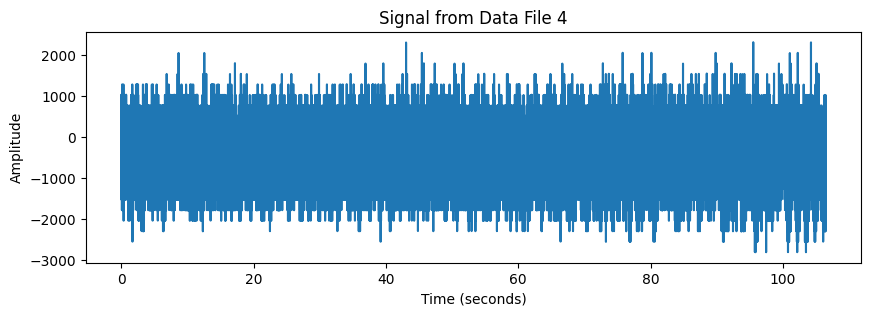

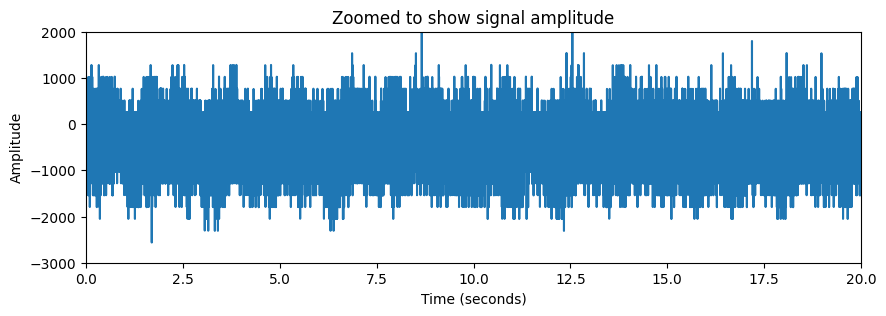

In [6]:

# Parse the header file
# Here you should read the raw data as a stream of bytes. The easiest way is using the fromfile routine in numpy.
# https://docs.scipy.org/doc/numpy-1.13.0/reference/generated/numpy.fromfile.html

header = {}

with open(os.path.join(data_directory, hdrfile)) as f:
    for line in f:   # loop through each line
        line = line.strip() # remove whitespace
        if not line:
            continue  # skip blank lines
        parts = line.split() #break line into pieces of strings
        key = parts[0] ##first item as field name
        value = " ".join(parts[1:]) #and then the value
        header[key] = value #recombine as single string

# Extract sampling interval from header
dt = float(header.get("Tsamp", 0.01)) /1000  # default to 0.01 if missing, div by 1000 since it is in milliseconds

# Read the binary data
data_file = os.path.join(data_directory, myfile)
data = np.fromfile(data_file, dtype=np.int16)

# Compute total observation time
total_time = len(data) * dt

print()
print(f"Loaded {len(data)} samples")
print(f"First few samples: {data[:10]}")
print(f"Tsamp = {dt} seconds")
print(f"Total observation time = {total_time:.2f} seconds")

# For the real pulsar signals, you will have to read the data and determine the number of points from the data array.
samples = len(data)
t = np.linspace(0,(samples-1)*dt,samples) #it's in miliseconds
raw_bytes = data


# We can plot the data.
print("Total observation time is {} seconds".format(len(data) * dt))

plt.figure(figsize=(10,3))
plt.plot(t,raw_bytes)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Signal from Data File 4")


# create a new figure zoomed to show the signal.
plt.figure(figsize=(10,3))
plt.plot(t,raw_bytes)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Zoomed to show signal amplitude")
plt.xlim(0,20)
plt.ylim(-3000,2000)
plt.show()

## The FFT

This part of the code executes the Fourier transform using the Fast Fourier transform algorithm (FFT). See the numpy reference page for the FFT module for an understanding of what the algorithm actually computes.

https://docs.scipy.org/doc/numpy-1.13.0/reference/routines.fft.html

In this demo, we use the "rfft" routine since we are computing a transform on real data. You will need to compute the x-values to plot for the frequency axis. Check that the frequency of the signal in your power spectrum matches the period you set in the simulation code.

For your real data, you might have some very strong signals, and therefore have to re-scale the axes to identify the pulsar signals. It could help to first plot the logarithm of the power to compress the brightest signals.

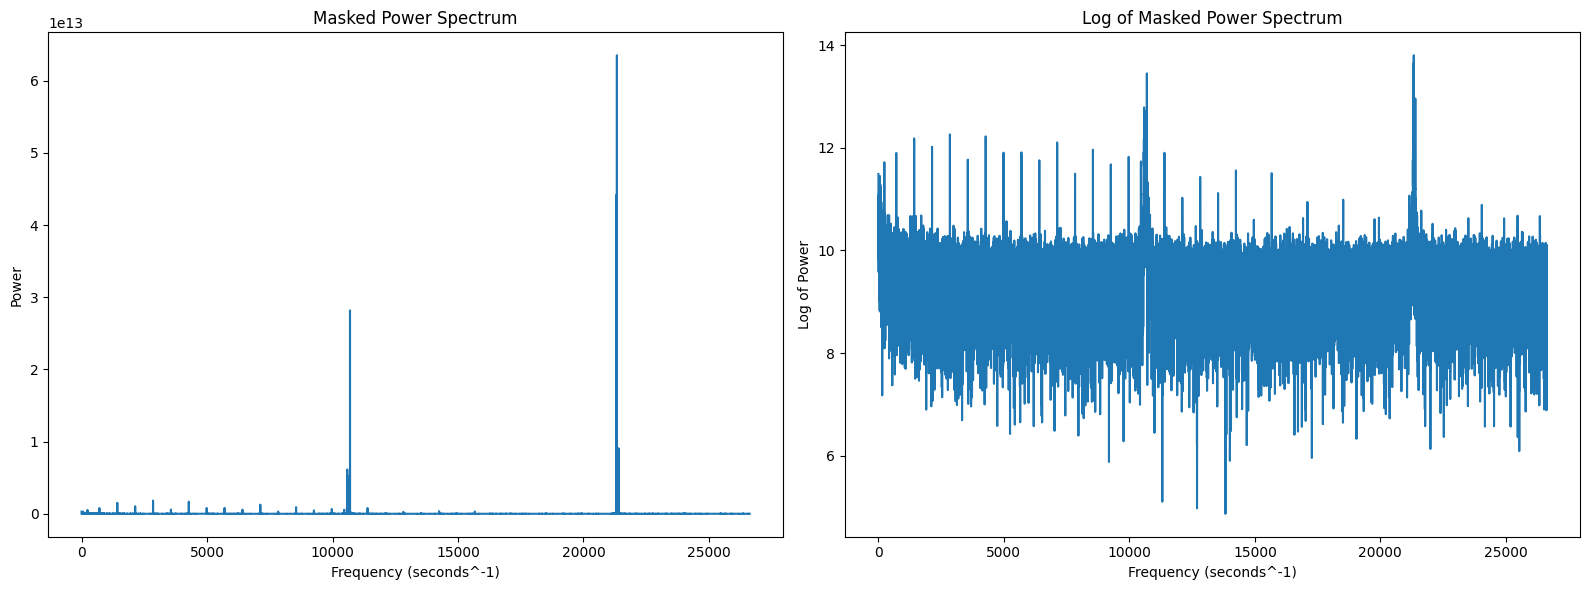

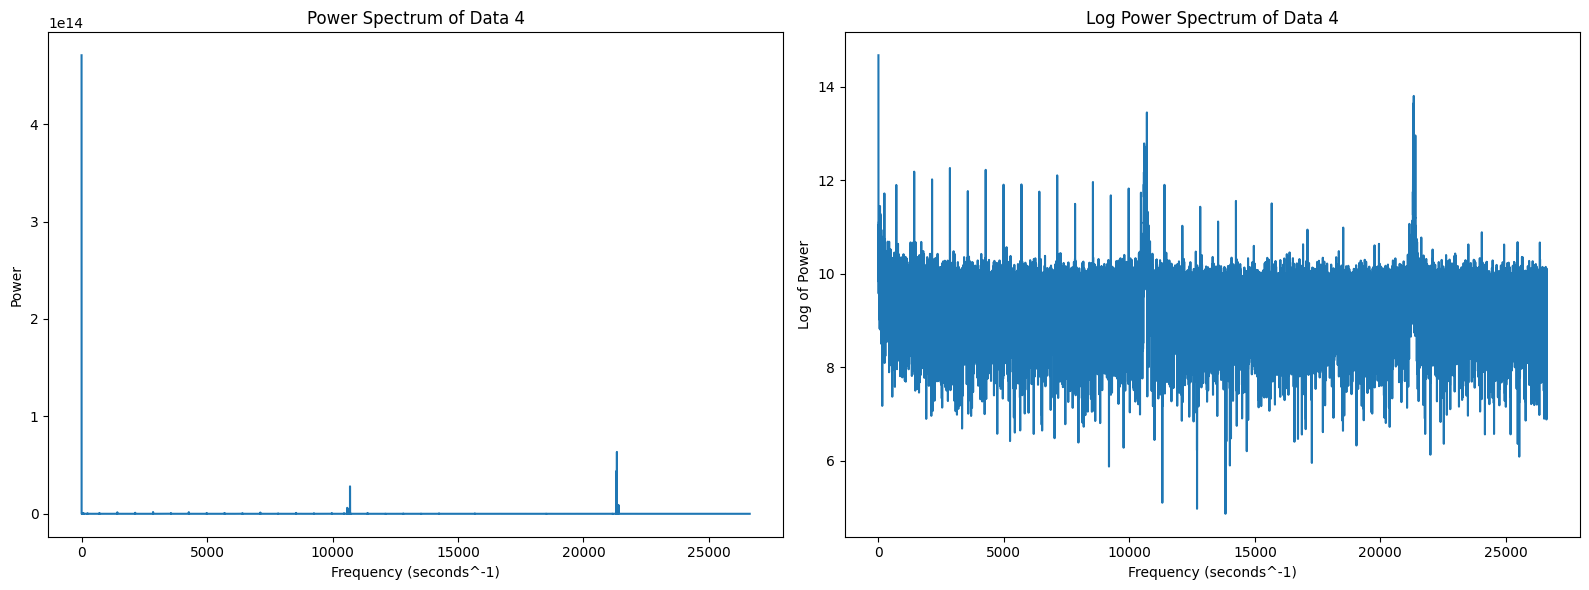

In [15]:
ft = np.fft.rfft(raw_bytes)

# The Fourier transform of a real-valued sequence sill creates complex values. Here we just take the "power spectrum".
# Note that the real() function from numpy operates on the entire array of numbers, and the multiply and add operators
# act over the entire array, summing elementwise.
power = np.real(ft)*np.real(ft) + np.imag(ft)*np.imag(ft)

mask = (power <= 1e14)
power_clean = power[mask]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Normal masked power
axes[0].plot(power_clean)
axes[0].set_xlabel("Frequency (seconds^-1)")
axes[0].set_ylabel("Power")
axes[0].set_title("Masked Power Spectrum")

# Log masked power
axes[1].plot(np.log10(power_clean))
axes[1].set_xlabel("Frequency (seconds^-1)")
axes[1].set_ylabel("Log of Power")
axes[1].set_title("Log of Masked Power Spectrum")

plt.tight_layout()
plt.show()

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Normal unmasked power
axes[0].plot(power)
axes[0].set_xlabel("Frequency (seconds^-1)")
axes[0].set_ylabel("Power")
axes[0].set_title("Power Spectrum of Data 4")

# Logarithm of unmasked power
logged_power = np.log10(power)
axes[1].plot(logged_power)
axes[1].set_xlabel("Frequency (seconds^-1)")
axes[1].set_ylabel("Log of Power")
axes[1].set_title("Log Power Spectrum of Data 4")

plt.tight_layout()
plt.show()

